# 03 · Modelo XGBoost

Proyecto de titulación · Maestría en Inteligencia Artificial Aplicada (UDLA)
Amapola Technologies Corp.

Este notebook entrena sobre `outputs/dataset_modelado_v1.csv`, el cual contiene 18.580 cliente-mes
correspondientes a 9.906 clientes. Las decisiones metodológicas adoptadas son las siguientes:

- Se utiliza una partición temporal, entrenando con el período de julio de 2025 a enero de 2026 y
  evaluando de febrero a abril de 2026, dado que la cobertura del chatbot sube del 5 % al 30 %
  dentro de la ventana y una partición aleatoria filtraría información del futuro.
- La validación cruzada agrupa por `id_anonimo`, ya que un mismo cliente puede aparecer hasta en
  diez meses y sin agrupar quedaría simultáneamente en entrenamiento y validación.
- El desbalance de 3,88 a 1 se maneja mediante `scale_pos_weight`.
- Se adopta PR-AUC como métrica principal, puesto que con clase positiva minoritaria el ROC-AUC
  resulta optimista por efecto de los verdaderos negativos.
- Se excluyen `lote_control` y `mes` del conjunto de variables, dado que cada lote cubre uno o dos
  meses y por ende constituyen proxies del calendario que en el conjunto de prueba serían
  categorías nunca vistas.

### Consideración sobre `activo_ya_pague`

Las variables conversacionales se agregan sobre el mes completo, mientras que la variable objetivo
corresponde al pago de ese mismo mes. Al contrastar la marca de tiempo de cada intención contra la
fecha de pago se obtiene lo siguiente:

| intención | antes del pago | mismo día | después | mediana |
|---|---|---|---|---|
| `ya_pague` | 38,6 % | 33,1 % | 28,3 % | **0 días** |
| `compromiso` | 73,6 % | 7,6 % | 18,8 % | **−6 días** |

La intención de compromiso precede al pago, motivo por el cual resulta legítimamente predictiva. En
cambio, la intención `ya_pague` presenta mediana de cero días y hasta un 61 % de los eventos ocurre
el mismo día o con posterioridad, de modo que constituye en buena medida una confirmación de que el
pago ya se produjo. Por ende, un modelo que la utilice reportaría un desempeño que no podría
reproducir en producción, donde la predicción se realiza de manera anticipada.

Dado que dicha variable forma parte de las diez establecidas en la especificación, se entrenan dos
modelos y se reporta la diferencia entre ambos. El modelo completo documenta la especificación,
mientras que el modelo operativo, que la excluye, es el que debe utilizarse para decidir.

## 0 · Configuración

In [1]:
import json
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
import joblib
import xgboost as xgb

from sklearn.model_selection import StratifiedGroupKFold, RandomizedSearchCV
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.metrics import (average_precision_score, roc_auc_score, brier_score_loss,
                             precision_recall_curve, roc_curve, confusion_matrix,
                             classification_report)
from sklearn.calibration import calibration_curve

warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=UserWarning)
pd.set_option("display.max_columns", 120)
pd.set_option("display.width", 220)
SEMILLA = 42

RAIZ = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
DIR_OUTPUTS = RAIZ / "outputs"
DIR_FIGURAS = DIR_OUTPUTS / "figuras"
DIR_MODELOS = RAIZ / "modelos"
for d in (DIR_FIGURAS, DIR_MODELOS):
    d.mkdir(parents=True, exist_ok=True)

print("xgboost:", xgb.__version__)

xgboost: 3.2.0


In [2]:
# Paleta validada (ver 02_eda). Una serie -> un color; sin dobles ejes.
AZUL, NARANJA, AQUA = "#2a78d6", "#eb6834", "#1baf7a"
SUPERFICIE, TINTA, TINTA_2 = "#fcfcfb", "#0b0b0b", "#52514e"
MUTED, REJILLA, EJE = "#898781", "#e1e0d9", "#c3c2b7"

mpl.rcParams.update({
    "figure.facecolor": SUPERFICIE, "axes.facecolor": SUPERFICIE,
    "savefig.facecolor": SUPERFICIE, "font.family": "sans-serif",
    "font.sans-serif": ["Segoe UI", "DejaVu Sans", "sans-serif"], "font.size": 10,
    "text.color": TINTA, "axes.labelcolor": TINTA_2, "axes.edgecolor": EJE,
    "axes.linewidth": 0.8, "axes.grid": True, "axes.axisbelow": True,
    "grid.color": REJILLA, "grid.linewidth": 0.8, "grid.linestyle": "-",
    "xtick.color": MUTED, "ytick.color": MUTED, "xtick.labelsize": 9,
    "ytick.labelsize": 9, "legend.frameon": False, "legend.fontsize": 9,
    "figure.dpi": 110, "savefig.dpi": 200, "savefig.bbox": "tight",
})

def limpiar(ax):
    for lado in ("top", "right"):
        ax.spines[lado].set_visible(False)
    ax.tick_params(length=0)
    return ax

def titulos(ax, titulo, subtitulo=None):
    if subtitulo:
        ax.text(0, 1.13, titulo, transform=ax.transAxes, fontsize=12,
                fontweight="600", color=TINTA, va="bottom")
        ax.text(0, 1.035, subtitulo, transform=ax.transAxes, fontsize=9,
                color=MUTED, va="bottom")
    else:
        ax.text(0, 1.035, titulo, transform=ax.transAxes, fontsize=12,
                fontweight="600", color=TINTA, va="bottom")

def guardar(fig, nombre):
    ruta = DIR_FIGURAS / f"{nombre}.png"
    fig.savefig(ruta)
    print(f"figura -> {ruta.relative_to(RAIZ)}")

---
## 1 · Datos y conjuntos de variables

In [3]:
df = pd.read_csv(DIR_OUTPUTS / "dataset_modelado_v1.csv", dtype={"mes": str, "id_anonimo": str})

TARGET = "cumplimiento_conciliado"
PROXY = "cumplimiento_ceroteo"
GRUPO = "id_anonimo"

NUMERICAS = [
    "total_intenciones", "intenciones_distintas", "activo_compromiso", "dias_compromiso",
    "activo_ya_pague", "hora_primera_interaccion", "dia_semana_primera_interaccion",
    "dias_mora_inicial", "meses_consecutivos_mora", "mes_campania", "tiene_conversacion",
]
CATEGORICAS = ["ultima_intencion_antes_compromiso", "tipo_operacion", "bucket"]

# Fuera del modelo a proposito
EXCLUIDAS = {"id_anonimo", "mes", "lote_control", TARGET, PROXY}
print("Excluidas del modelo:", sorted(EXCLUIDAS))

FEATURES_COMPLETO = NUMERICAS + CATEGORICAS
FEATURES_OPERATIVO = [c for c in FEATURES_COMPLETO if c != "activo_ya_pague"]

print(f"\nFeatures completo : {len(FEATURES_COMPLETO)}")
print(f"Features operativo: {len(FEATURES_OPERATIVO)} (sin activo_ya_pague)")
print(f"\nDataset: {df.shape} | positivos {df[TARGET].mean():.2%}")
display(df.head(3))

Excluidas del modelo: ['cumplimiento_ceroteo', 'cumplimiento_conciliado', 'id_anonimo', 'lote_control', 'mes']

Features completo : 14
Features operativo: 13 (sin activo_ya_pague)

Dataset: (18580, 20) | positivos 20.49%


,id_anonimo,mes,total_intenciones,intenciones_distintas,activo_compromiso,dias_compromiso,activo_ya_pague,ultima_intencion_antes_compromiso,hora_primera_interaccion,dia_semana_primera_interaccion,dias_mora_inicial,meses_consecutivos_mora,tipo_operacion,bucket,mes_campania,lote_control,tiene_conversacion,cumplimiento_conciliado,cumplimiento_ceroteo,rango_mora
0,6dbc81b965ac2689d337e5018601ec233e35fa3530eccd...,202602,0,0,0,NaN,0,SIN_DATOS,NaN,NaN,81,1,TC,B3,15.0,53_ad,0,0,0,61-90
1,8df2fe9cf302666604e6ac711b2c1f9bd37b59a704a9f1...,202509,0,0,0,NaN,0,SIN_DATOS,NaN,NaN,21,1,TC,B1,9.0,39,0,1,1,16-30
2,e658bb569a33659187829819d29a60ab1db4a8e6933729...,202509,1,1,0,NaN,0,NO_APLICA,14.0,0.0,21,1,TC,B1,9.0,39,1,1,0,16-30


In [4]:
def preparar(d, features):
    X = d[features].copy()
    for c in features:
        if c in CATEGORICAS:
            X[c] = X[c].astype("category")
        else:
            X[c] = pd.to_numeric(X[c], errors="coerce")
    return X

MES_CORTE = "202602"
tr = df[df["mes"] < MES_CORTE]
te = df[df["mes"] >= MES_CORTE]

print("=" * 66)
print("SPLIT TEMPORAL")
print("=" * 66)
for etiqueta, parte in [("TRAIN", tr), ("TEST", te)]:
    print(f"{etiqueta:<6} {len(parte):>6,} filas | {parte[GRUPO].nunique():>5,} clientes | "
          f"meses {parte['mes'].min()}-{parte['mes'].max()} | positivos {parte[TARGET].mean():.2%}")

solapan = set(tr[GRUPO]) & set(te[GRUPO])
print(f"\nClientes presentes en train y test: {len(solapan):,}")
print("Es esperable y correcto: el split es temporal, no por cliente. La separacion por")
print("cliente se aplica en la validacion cruzada dentro de train (StratifiedGroupKFold).")

y_tr, y_te = tr[TARGET].to_numpy(), te[TARGET].to_numpy()
g_tr = tr[GRUPO].to_numpy()
spw = (y_tr == 0).sum() / (y_tr == 1).sum()
print(f"\nscale_pos_weight (calculado solo en train): {spw:.3f}")

SPLIT TEMPORAL
TRAIN  11,078 filas | 6,416 clientes | meses 202507-202601 | positivos 22.68%
TEST    7,502 filas | 4,992 clientes | meses 202602-202604 | positivos 17.25%

Clientes presentes en train y test: 1,502
Es esperable y correcto: el split es temporal, no por cliente. La separacion por
cliente se aplica en la validacion cruzada dentro de train (StratifiedGroupKFold).

scale_pos_weight (calculado solo en train): 3.408


---
## 2 · Líneas base

Sin una referencia, un PR-AUC no significa nada. Con 20 % de positivos, un clasificador aleatorio
ya obtiene PR-AUC ≈ 0,20. Se comparan dos referencias: la tasa base y una regresión logística.

In [5]:
def evaluar(nombre, y_real, p_pred, registro=None):
    m = {
        "modelo": nombre,
        "PR_AUC": average_precision_score(y_real, p_pred),
        "ROC_AUC": roc_auc_score(y_real, p_pred),
        "Brier": brier_score_loss(y_real, p_pred),
    }
    if registro is not None:
        registro.append(m)
    return m

resultados = []

# Referencia 1: predecir siempre la tasa base
dummy = DummyClassifier(strategy="prior").fit(preparar(tr, FEATURES_OPERATIVO), y_tr)
p_dummy = dummy.predict_proba(preparar(te, FEATURES_OPERATIVO))[:, 1]
print(evaluar("Tasa base (dummy)", y_te, p_dummy, resultados))

# Referencia 2: regresion logistica con imputacion + one-hot
num_op = [c for c in FEATURES_OPERATIVO if c not in CATEGORICAS]
pre = ColumnTransformer([
    ("num", Pipeline([("imp", SimpleImputer(strategy="median")),
                      ("sc", StandardScaler())]), num_op),
    ("cat", Pipeline([("imp", SimpleImputer(strategy="most_frequent")),
                      ("oh", OneHotEncoder(handle_unknown="ignore", min_frequency=20))]),
     CATEGORICAS),
])
logit = Pipeline([("pre", pre),
                  ("clf", LogisticRegression(max_iter=2000, class_weight="balanced",
                                             random_state=SEMILLA))])
logit.fit(tr[FEATURES_OPERATIVO], y_tr)
p_logit = logit.predict_proba(te[FEATURES_OPERATIVO])[:, 1]
print(evaluar("Logistica operativa", y_te, p_logit, resultados))

# La misma logistica con el set completo, para que la comparacion sea simetrica
num_full = [c for c in FEATURES_COMPLETO if c not in CATEGORICAS]
pre_full = ColumnTransformer([
    ("num", Pipeline([("imp", SimpleImputer(strategy="median")),
                      ("sc", StandardScaler())]), num_full),
    ("cat", Pipeline([("imp", SimpleImputer(strategy="most_frequent")),
                      ("oh", OneHotEncoder(handle_unknown="ignore", min_frequency=20))]),
     CATEGORICAS),
])
logit_full = Pipeline([("pre", pre_full),
                       ("clf", LogisticRegression(max_iter=2000, class_weight="balanced",
                                                  random_state=SEMILLA))])
logit_full.fit(tr[FEATURES_COMPLETO], y_tr)
p_logit_full = logit_full.predict_proba(te[FEATURES_COMPLETO])[:, 1]
print(evaluar("Logistica completa", y_te, p_logit_full, resultados))

{'modelo': 'Tasa base (dummy)', 'PR_AUC': 0.1724873367102106, 'ROC_AUC': 0.5, 'Brier': 0.14569031977724736}


{'modelo': 'Logistica operativa', 'PR_AUC': 0.42087588328030145, 'ROC_AUC': 0.7643706978281999, 'Brier': 0.14205600613462552}


{'modelo': 'Logistica completa', 'PR_AUC': 0.4543367055051839, 'ROC_AUC': 0.7723500065727625, 'Brier': 0.13769713409623838}


---
## 3 · XGBoost: búsqueda de hiperparámetros

La búsqueda se hace **solo sobre train**; el test no se toca hasta la sección 4. Se comparan dos
criterios de selección, porque no dan lo mismo:

- **CV aleatoria por grupos** (`StratifiedGroupKFold` por `id_anonimo`): evita que un cliente esté
  a la vez en train y validación, pero mezcla meses. Mide capacidad de generalizar **a otros
  clientes**.
- **CV temporal expansiva**: entrena con los meses previos y valida con el siguiente, avanzando en
  el tiempo. Mide capacidad de generalizar **al futuro**, que es el régimen real de despliegue.

El modelo se selecciona con la **temporal**, porque es la que reproduce cómo se va a usar. La
aleatoria se conserva como comparación: la diferencia entre ambas es un resultado en sí mismo.

In [6]:
cv = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=SEMILLA)

meses_train = sorted(tr["mes"].unique())
serie_mes = tr["mes"].to_numpy()

def folds_temporales(min_meses_train=3):
    """Ventana expansiva: entrena con los meses previos, valida con el siguiente."""
    folds, etiquetas = [], []
    for i in range(min_meses_train, len(meses_train)):
        m_tr, m_va = meses_train[:i], meses_train[i]
        idx_tr = np.flatnonzero(np.isin(serie_mes, m_tr))
        idx_va = np.flatnonzero(serie_mes == m_va)
        if len(idx_va) and 0 < y_tr[idx_va].sum() < len(idx_va):
            folds.append((idx_tr, idx_va))
            etiquetas.append((m_tr[0], m_tr[-1], m_va))
    return folds, etiquetas

cv_temporal, etiq_temporal = folds_temporales()
print(f"Meses en train: {meses_train}")
print(f"Folds temporales: {len(cv_temporal)}")
for k, ((a, b), (ini, fin, val)) in enumerate(zip(cv_temporal, etiq_temporal), 1):
    print(f"  fold {k}: train {ini}-{fin} ({len(a):>6,} filas) -> valida {val} ({len(b):>5,} filas)")

# Paralelismo: XGBoost con un hilo dentro de cada ajuste y la busqueda repartida en
# 4 procesos. Anidar n_jobs=-1 en ambos niveles agota los handles de Windows
# (OSError WinError 1450) cuando se encadenan varias busquedas.
N_JOBS_BUSQUEDA = 4
N_JOBS_MODELO = 1

ESPACIO = {
    "max_depth": [3, 4, 5, 6],
    "learning_rate": [0.02, 0.05, 0.1],
    "n_estimators": [200, 400, 600],
    "min_child_weight": [1, 5, 10, 20],
    "subsample": [0.7, 0.85, 1.0],
    "colsample_bytree": [0.6, 0.8, 1.0],
    "reg_lambda": [1, 5, 20],
    "gamma": [0, 0.5, 2],
}

def buscar(features, etiqueta, particion, grupos=None):
    X = preparar(tr, features)
    base = xgb.XGBClassifier(
        objective="binary:logistic", eval_metric="aucpr", tree_method="hist",
        enable_categorical=True, scale_pos_weight=spw, random_state=SEMILLA, n_jobs=N_JOBS_MODELO,
    )
    busqueda = RandomizedSearchCV(
        base, ESPACIO, n_iter=40, scoring="average_precision", cv=particion,
        random_state=SEMILLA, n_jobs=N_JOBS_BUSQUEDA, refit=True, verbose=0,
    )
    busqueda.fit(X, y_tr, groups=grupos)
    print(f"[{etiqueta}] PR-AUC en CV    : {busqueda.best_score_:.4f}")
    print(f"[{etiqueta}] hiperparametros : {busqueda.best_params_}")
    return busqueda

busq_grupo = buscar(FEATURES_OPERATIVO, "operativo · CV aleatoria por grupos", cv, g_tr)

Meses en train: ['202507', '202508', '202509', '202510', '202511', '202512', '202601']
Folds temporales: 4
  fold 1: train 202507-202509 ( 5,160 filas) -> valida 202510 (1,296 filas)
  fold 2: train 202507-202510 ( 6,456 filas) -> valida 202511 (1,618 filas)
  fold 3: train 202507-202511 ( 8,074 filas) -> valida 202512 (1,430 filas)
  fold 4: train 202507-202512 ( 9,504 filas) -> valida 202601 (1,574 filas)


[operativo · CV aleatoria por grupos] PR-AUC en CV    : 0.5477
[operativo · CV aleatoria por grupos] hiperparametros : {'subsample': 0.7, 'reg_lambda': 1, 'n_estimators': 400, 'min_child_weight': 10, 'max_depth': 4, 'learning_rate': 0.05, 'gamma': 0.5, 'colsample_bytree': 0.6}


In [7]:
busq_op = buscar(FEATURES_OPERATIVO, "operativo · CV temporal", cv_temporal)

[operativo · CV temporal] PR-AUC en CV    : 0.4993
[operativo · CV temporal] hiperparametros : {'subsample': 0.85, 'reg_lambda': 1, 'n_estimators': 600, 'min_child_weight': 10, 'max_depth': 3, 'learning_rate': 0.02, 'gamma': 0, 'colsample_bytree': 1.0}


In [8]:
busq_full = buscar(FEATURES_COMPLETO, "completo · CV temporal", cv_temporal)

print()
print("Profundidad elegida por cada criterio:")
print(f"  CV aleatoria por grupos : max_depth={busq_grupo.best_params_['max_depth']}, "
      f"min_child_weight={busq_grupo.best_params_['min_child_weight']}")
print(f"  CV temporal             : max_depth={busq_op.best_params_['max_depth']}, "
      f"min_child_weight={busq_op.best_params_['min_child_weight']}")

[completo · CV temporal] PR-AUC en CV    : 0.5229
[completo · CV temporal] hiperparametros : {'subsample': 0.85, 'reg_lambda': 20, 'n_estimators': 200, 'min_child_weight': 5, 'max_depth': 3, 'learning_rate': 0.05, 'gamma': 0, 'colsample_bytree': 0.6}

Profundidad elegida por cada criterio:
  CV aleatoria por grupos : max_depth=4, min_child_weight=10
  CV temporal             : max_depth=3, min_child_weight=10


### 3.1 · Restricciones de monotonía

Que un modelo lineal generalice mejor sugiere que las relaciones de este problema son
esencialmente monótonas y que los árboles están gastando capacidad en curvas que no transfieren
entre períodos. Las **restricciones de monotonía** conservan la estructura de árbol pero prohíben
que la predicción se mueva en contra de una dirección declarada.

La dirección de cada variable sale del EDA, no de la intuición. Solo se restringe donde la
evidencia es clara y monótona; el resto queda libre:

| Variable | Restricción | Evidencia (02_eda) |
|---|---|---|
| `dias_mora_inicial` | ↓ | Tasa cae de 40,8 % a 1,4 % al aumentar la mora |
| `meses_consecutivos_mora` | ↓ | Caída sostenida con la racha |
| `total_intenciones` | ↑ | Sube de forma monótona por rango de volumen |
| `intenciones_distintas` | ↑ | Spearman +0,226 |
| `activo_compromiso` | ↑ | Binaria, activar > no activar |
| `activo_ya_pague` | ↑ | Binaria, activar > no activar |
| `dias_compromiso` | libre | Solo tres niveles y confundida con quién adquiere compromiso |
| `hora`, `dia_semana`, `mes_campania` | libres | Sin dirección clara (Spearman ≈ 0) |
| Categóricas | libres | La monotonía no aplica a variables sin orden |

Un riesgo que conviene nombrar: si una dirección declarada fuese falsa, la restricción **degrada**
el modelo en lugar de ayudarlo. Por eso solo se restringen las seis con evidencia sólida.

In [9]:
DIRECCION = {
    "dias_mora_inicial": -1,
    "meses_consecutivos_mora": -1,
    "total_intenciones": +1,
    "intenciones_distintas": +1,
    "activo_compromiso": +1,
    "activo_ya_pague": +1,
    "tiene_conversacion": +1,
}

def restricciones(features):
    """Tupla alineada al orden de las columnas; 0 = sin restriccion."""
    return tuple(DIRECCION.get(c, 0) for c in features)

def buscar_monotono(features, etiqueta, particion):
    X = preparar(tr, features)
    cons = restricciones(features)
    print(f"[{etiqueta}] restricciones: "
          f"{ {c: d for c, d in zip(features, cons) if d} }")
    base = xgb.XGBClassifier(
        objective="binary:logistic", eval_metric="aucpr", tree_method="hist",
        enable_categorical=True, scale_pos_weight=spw, random_state=SEMILLA, n_jobs=N_JOBS_MODELO,
        monotone_constraints=cons,
    )
    busqueda = RandomizedSearchCV(
        base, ESPACIO, n_iter=40, scoring="average_precision", cv=particion,
        random_state=SEMILLA, n_jobs=N_JOBS_BUSQUEDA, refit=True, verbose=0,
    )
    busqueda.fit(X, y_tr)
    print(f"[{etiqueta}] PR-AUC en CV    : {busqueda.best_score_:.4f}")
    print(f"[{etiqueta}] hiperparametros : {busqueda.best_params_}")
    return busqueda

busq_mono = buscar_monotono(FEATURES_OPERATIVO, "operativo monotono", cv_temporal)

[operativo monotono] restricciones: {'total_intenciones': 1, 'intenciones_distintas': 1, 'activo_compromiso': 1, 'dias_mora_inicial': -1, 'meses_consecutivos_mora': -1, 'tiene_conversacion': 1}


[operativo monotono] PR-AUC en CV    : 0.4987
[operativo monotono] hiperparametros : {'subsample': 0.85, 'reg_lambda': 1, 'n_estimators': 600, 'min_child_weight': 10, 'max_depth': 3, 'learning_rate': 0.02, 'gamma': 0, 'colsample_bytree': 1.0}


In [10]:
busq_mono_full = buscar_monotono(FEATURES_COMPLETO, "completo monotono", cv_temporal)

[completo monotono] restricciones: {'total_intenciones': 1, 'intenciones_distintas': 1, 'activo_compromiso': 1, 'activo_ya_pague': 1, 'dias_mora_inicial': -1, 'meses_consecutivos_mora': -1, 'tiene_conversacion': 1}


[completo monotono] PR-AUC en CV    : 0.5209
[completo monotono] hiperparametros : {'subsample': 0.85, 'reg_lambda': 20, 'n_estimators': 200, 'min_child_weight': 5, 'max_depth': 6, 'learning_rate': 0.05, 'gamma': 2, 'colsample_bytree': 0.8}


#### Resultado: la restricción no mejora el modelo

Adelantando lo que confirma la sección 4, las restricciones de monotonía no mejoran el desempeño,
ya que el modelo operativo empeora en 0,003 y el completo en 0,031. Por ende, la hipótesis queda
refutada.

Sin embargo, se trata de un resultado negativo igualmente informativo, dado que descarta que la
desventaja de XGBoost provenga de ajustar curvas no monótonas que no transfieren entre períodos. Si
ese fuera el mecanismo, prohibirlas habría cerrado la brecha. Es decir, la ventaja del modelo lineal
no radica en la forma de las relaciones sino, con toda probabilidad, en la relación entre el volumen
de datos disponible y la capacidad del modelo, puesto que 11.078 filas no alcanzan para que el
método de boosting estime interacciones estables.

Cabe aclarar que un experimento que descarta una explicación plausible resulta igualmente valioso
que uno que confirma otra, además de evitar que quien retome el trabajo repita el intento.

---
## 4 · Evaluación en el conjunto de test

In [11]:
mod_op, mod_full = busq_op.best_estimator_, busq_full.best_estimator_
mod_grupo = busq_grupo.best_estimator_
p_op = mod_op.predict_proba(preparar(te, FEATURES_OPERATIVO))[:, 1]
p_full = mod_full.predict_proba(preparar(te, FEATURES_COMPLETO))[:, 1]
p_grupo = mod_grupo.predict_proba(preparar(te, FEATURES_OPERATIVO))[:, 1]

mod_mono, mod_mono_full = busq_mono.best_estimator_, busq_mono_full.best_estimator_
p_mono = mod_mono.predict_proba(preparar(te, FEATURES_OPERATIVO))[:, 1]
p_mono_full = mod_mono_full.predict_proba(preparar(te, FEATURES_COMPLETO))[:, 1]

print(evaluar("XGBoost operativo · CV aleatoria", y_te, p_grupo, resultados))
print(evaluar("XGBoost operativo · CV temporal", y_te, p_op, resultados))
print(evaluar("XGBoost operativo · monotono", y_te, p_mono, resultados))
print(evaluar("XGBoost completo · CV temporal", y_te, p_full, resultados))
print(evaluar("XGBoost completo · monotono", y_te, p_mono_full, resultados))

tabla = pd.DataFrame(resultados).set_index("modelo").round(4)
tabla["PR_AUC_lift"] = (tabla["PR_AUC"] / y_te.mean()).round(2)
display(tabla)
print(f"\nTasa base en test: {y_te.mean():.4f}, que es el PR-AUC de un clasificador aleatorio.")
print()
print("Optimismo de cada criterio de seleccion (CV en train frente a test):")
for etiqueta, b, p in [("CV aleatoria por grupos", busq_grupo, p_grupo),
                       ("CV temporal            ", busq_op, p_op),
                       ("CV temporal + monotonia", busq_mono, p_mono)]:
    real = average_precision_score(y_te, p)
    print(f"  {etiqueta}: {b.best_score_:.4f} -> {real:.4f}  (cae {b.best_score_ - real:+.4f})")

print()
print("Efecto de la monotonia sobre XGBoost:")
print(f"  operativo: {average_precision_score(y_te, p_op):.4f} -> "
      f"{average_precision_score(y_te, p_mono):.4f}  "
      f"({average_precision_score(y_te, p_mono) - average_precision_score(y_te, p_op):+.4f})")
print(f"  completo : {average_precision_score(y_te, p_full):.4f} -> "
      f"{average_precision_score(y_te, p_mono_full):.4f}  "
      f"({average_precision_score(y_te, p_mono_full) - average_precision_score(y_te, p_full):+.4f})")
print(f"\nReferencia lineal: operativa {average_precision_score(y_te, p_logit):.4f} | "
      f"completa {average_precision_score(y_te, p_logit_full):.4f}")

{'modelo': 'XGBoost operativo · CV aleatoria', 'PR_AUC': 0.37818861114360414, 'ROC_AUC': 0.7647717234779075, 'Brier': 0.1601075381040573}
{'modelo': 'XGBoost operativo · CV temporal', 'PR_AUC': 0.392274019658702, 'ROC_AUC': 0.7750529306553642, 'Brier': 0.16352541744709015}
{'modelo': 'XGBoost operativo · monotono', 'PR_AUC': 0.38946240216418293, 'ROC_AUC': 0.7736603888486113, 'Brier': 0.16654656827449799}
{'modelo': 'XGBoost completo · CV temporal', 'PR_AUC': 0.44580136020602734, 'ROC_AUC': 0.7911896849455855, 'Brier': 0.16156072914600372}
{'modelo': 'XGBoost completo · monotono', 'PR_AUC': 0.4066942721795531, 'ROC_AUC': 0.7816197801311366, 'Brier': 0.16234636306762695}


,PR_AUC,ROC_AUC,Brier,PR_AUC_lift
modelo,,,,
Tasa base (dummy),0.1725,0.5000,0.1457,1.00
Logistica operativa,0.4209,0.7644,0.1421,2.44
Logistica completa,0.4543,0.7724,0.1377,2.63
XGBoost operativo · CV aleatoria,0.3782,0.7648,0.1601,2.19
XGBoost operativo · CV temporal,0.3923,0.7751,0.1635,2.27
XGBoost operativo · monotono,0.3895,0.7737,0.1665,2.26
XGBoost completo · CV temporal,0.4458,0.7912,0.1616,2.58
XGBoost completo · monotono,0.4067,0.7816,0.1623,2.36



Tasa base en test: 0.1725, que es el PR-AUC de un clasificador aleatorio.

Optimismo de cada criterio de seleccion (CV en train frente a test):
  CV aleatoria por grupos: 0.5477 -> 0.3782  (cae +0.1695)
  CV temporal            : 0.4993 -> 0.3923  (cae +0.1070)
  CV temporal + monotonia: 0.4987 -> 0.3895  (cae +0.1092)

Efecto de la monotonia sobre XGBoost:
  operativo: 0.3923 -> 0.3895  (-0.0028)
  completo : 0.4458 -> 0.4067  (-0.0391)

Referencia lineal: operativa 0.4209 | completa 0.4543


figura -> outputs\figuras\18_curvas_pr_roc.png


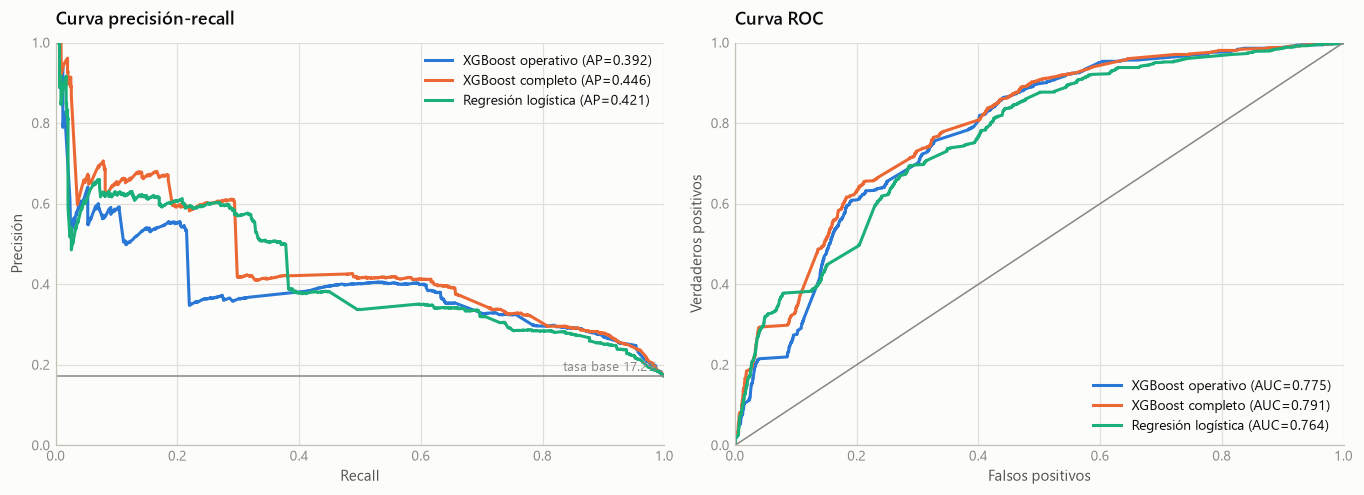

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(12.5, 4.6))

ax = axes[0]
for p, color, nombre in [(p_op, AZUL, "XGBoost operativo"),
                         (p_full, NARANJA, "XGBoost completo"),
                         (p_logit, AQUA, "Regresión logística")]:
    pr, rc, _ = precision_recall_curve(y_te, p)
    ax.plot(rc, pr, color=color, linewidth=2,
            label=f"{nombre} (AP={average_precision_score(y_te, p):.3f})")
ax.axhline(y_te.mean(), color=MUTED, linewidth=1)
ax.text(0.99, y_te.mean() + 0.012, f"tasa base {y_te.mean():.1%}", ha="right",
        fontsize=8.5, color=MUTED)
limpiar(ax)
ax.set_xlabel("Recall"); ax.set_ylabel("Precisión")
ax.set_xlim(0, 1); ax.set_ylim(0, 1)
ax.legend(loc="upper right")
titulos(ax, "Curva precisión-recall")

ax = axes[1]
for p, color, nombre in [(p_op, AZUL, "XGBoost operativo"),
                         (p_full, NARANJA, "XGBoost completo"),
                         (p_logit, AQUA, "Regresión logística")]:
    fpr, tpr, _ = roc_curve(y_te, p)
    ax.plot(fpr, tpr, color=color, linewidth=2,
            label=f"{nombre} (AUC={roc_auc_score(y_te, p):.3f})")
ax.plot([0, 1], [0, 1], color=MUTED, linewidth=1)
limpiar(ax)
ax.set_xlabel("Falsos positivos"); ax.set_ylabel("Verdaderos positivos")
ax.set_xlim(0, 1); ax.set_ylim(0, 1)
ax.legend(loc="lower right")
titulos(ax, "Curva ROC")

fig.tight_layout()
guardar(fig, "18_curvas_pr_roc")
plt.show()

### 4.1 · Umbral operativo

En cobranza la capacidad de gestión resulta limitada, dado que no se contacta a la totalidad de la
cartera sino que se prioriza. Por ende, la pregunta útil no es qué umbral maximiza el F1, sino
cuántos cumplidores se capturan si únicamente puede gestionarse un porcentaje determinado de la
cartera.

In [13]:
def curva_capacidad(y_real, p_pred, capacidades=(0.05, 0.10, 0.20, 0.30, 0.50)):
    orden = np.argsort(-p_pred)
    y_ord = np.asarray(y_real)[orden]
    total_pos = y_ord.sum()
    filas = []
    for k in capacidades:
        corte = max(1, int(len(y_ord) * k))
        capturados = y_ord[:corte].sum()
        filas.append({
            "capacidad": f"{k:.0%}",
            "gestionados": corte,
            "cumplidores_capturados": int(capturados),
            "precision": capturados / corte,
            "recall": capturados / total_pos,
            "lift": (capturados / corte) / y_ord.mean(),
        })
    return pd.DataFrame(filas)

print("XGBoost operativo (sin ya_pague):")
cap_op = curva_capacidad(y_te, p_op)
display(cap_op.round(3))

print("XGBoost completo:")
display(curva_capacidad(y_te, p_full).round(3))

print("Regresion logistica:")
display(curva_capacidad(y_te, p_logit).round(3))

XGBoost operativo (sin ya_pague):


,capacidad,gestionados,cumplidores_capturados,precision,recall,lift
0,5%,375,200,0.533,0.155,3.092
1,10%,750,283,0.377,0.219,2.188
2,20%,1500,598,0.399,0.462,2.311
3,30%,2250,821,0.365,0.634,2.115
4,50%,3751,1093,0.291,0.845,1.689


XGBoost completo:


,capacidad,gestionados,cumplidores_capturados,precision,recall,lift
0,5%,375,241,0.643,0.186,3.726
1,10%,750,385,0.513,0.298,2.976
2,20%,1500,633,0.422,0.489,2.447
3,30%,2250,850,0.378,0.657,2.190
4,50%,3751,1096,0.292,0.847,1.694


Regresion logistica:


,capacidad,gestionados,cumplidores_capturados,precision,recall,lift
0,5%,375,223,0.595,0.172,3.448
1,10%,750,419,0.559,0.324,3.239
2,20%,1500,574,0.383,0.444,2.219
3,30%,2250,785,0.349,0.607,2.023
4,50%,3751,1058,0.282,0.818,1.635


figura -> outputs\figuras\19_curva_lift.png


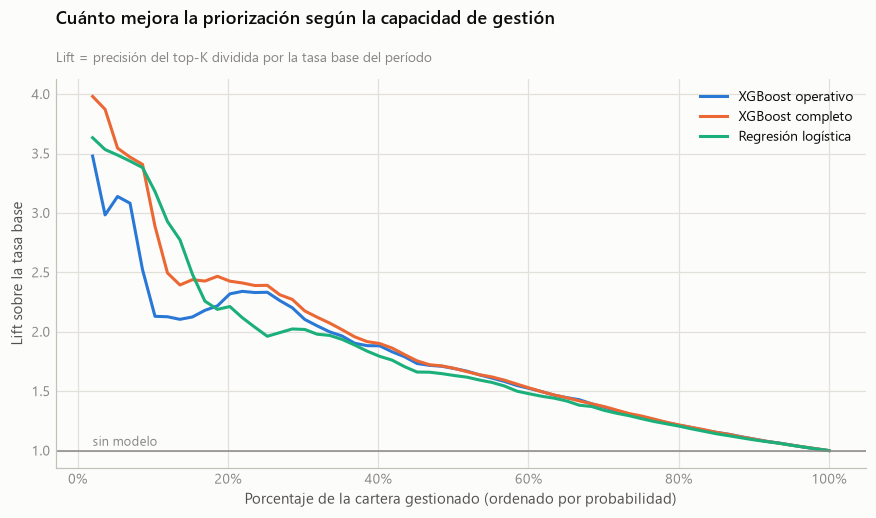

In [14]:
fig, ax = plt.subplots(figsize=(9.5, 4.6))
ks = np.linspace(0.02, 1.0, 60)
for p, color, nombre in [(p_op, AZUL, "XGBoost operativo"),
                         (p_full, NARANJA, "XGBoost completo"),
                         (p_logit, AQUA, "Regresión logística")]:
    orden = np.argsort(-p)
    y_ord = np.asarray(y_te)[orden]
    lifts = [(y_ord[:max(1, int(len(y_ord)*k))].mean()) / y_ord.mean() for k in ks]
    ax.plot(ks, lifts, color=color, linewidth=2, label=nombre)
ax.axhline(1, color=MUTED, linewidth=1)
ax.text(0.02, 1.04, "sin modelo", ha="left", fontsize=8.5, color=MUTED)
limpiar(ax)
ax.xaxis.set_major_formatter(mpl.ticker.PercentFormatter(1.0, decimals=0))
ax.set_xlabel("Porcentaje de la cartera gestionado (ordenado por probabilidad)")
ax.set_ylabel("Lift sobre la tasa base")
ax.legend(loc="upper right")
titulos(ax, "Cuánto mejora la priorización según la capacidad de gestión",
        "Lift = precisión del top-K dividida por la tasa base del período")
guardar(fig, "19_curva_lift")
plt.show()

### 4.1b · Comparación con la línea base

El resultado no coincide con lo previsto en la propuesta. La regresión logística supera a XGBoost en
PR-AUC con los dos conjuntos de variables y además presenta mejor calibración, dado que obtiene un
Brier más bajo. Cabe aclarar que XGBoost únicamente se impone en ROC-AUC, que constituye la métrica
menos informativa cuando las clases están desbalanceadas.

No es un error de implementación. Se probaron dos explicaciones y solo una sobrevive:

**Hipótesis descartada, relaciones no monótonas.** Si los árboles estuvieran ajustando curvas que no
transfieren, restringir la monotonía habría cerrado la brecha. Se probó (sección 3.1) y **empeoró**:
−0,003 en el operativo y −0,031 en el completo. La forma de las relaciones no es el problema.

**Hipótesis en pie, volumen insuficiente para la capacidad del modelo.** 11.078 filas de entrenamiento y 13 variables.
El boosting necesita volumen para estimar interacciones estables; sin él, la capacidad extra se
gasta en estructura específica del período de entrenamiento. Encaja con el desplazamiento temporal
observado: la tasa base cae de 22,7 % en train a 17,3 % en test, y el PR-AUC de XGBoost cae 0,107
de la CV temporal al test.

Ese último punto se ve en el propio experimento: cambiar el criterio de selección de CV aleatoria a
CV temporal **redujo el optimismo a la mitad** (de −0,158 a −0,107) aunque el desempeño final apenas
se movió. La CV aleatoria no elegía peores hiperparámetros: mentía sobre cuánto iban a rendir.

Para la memoria esto es un resultado, no un fracaso. La contribución del trabajo son las variables
conversacionales y el pipeline que las construye; que un modelo lineal las aproveche mejor que uno
de árboles es información útil sobre la naturaleza del problema. Lo deshonesto sería reportar solo
el número de XGBoost sin la línea base al lado.

### 4.1c · ¿La diferencia es real o cabe en el ruido?

Antes de declarar un ganador hay que saber si la brecha sobrevive al error de muestreo. Son 7.502
filas de test con 1.294 positivos y **un solo período**: una diferencia de 0,03 en PR-AUC podría ser
azar.

Se usa un **bootstrap pareado**: se remuestrea el test con reemplazo y se evalúan ambos modelos
sobre exactamente las mismas filas en cada réplica, de modo que la comparación no arrastre la
variabilidad del propio conjunto.

In [15]:
rng = np.random.default_rng(SEMILLA)
B, n_te = 2000, len(y_te)

def bootstrap_pareado(pa, pb, nombre_a, nombre_b):
    difs = []
    for _ in range(B):
        idx = rng.integers(0, n_te, n_te)
        if y_te[idx].sum() < 10:
            continue
        difs.append(average_precision_score(y_te[idx], pa[idx]) -
                    average_precision_score(y_te[idx], pb[idx]))
    difs = np.array(difs)
    lo, hi = np.percentile(difs, [2.5, 97.5])
    significativa = lo > 0 or hi < 0
    print(f"{nombre_a} vs {nombre_b}")
    print(f"   diferencia media : {difs.mean():+.4f}")
    print(f"   IC 95%           : [{lo:+.4f}, {hi:+.4f}]")
    print(f"   P(gana {nombre_a}): {(difs > 0).mean():.1%}")
    print(f"   -> {'DIFERENCIA SIGNIFICATIVA' if significativa else 'CABE EN EL RUIDO'}\n")
    return {"comparacion": f"{nombre_a} vs {nombre_b}", "diferencia": float(difs.mean()),
            "ic_bajo": float(lo), "ic_alto": float(hi), "significativa": bool(significativa)}

comparaciones = [
    bootstrap_pareado(p_logit, p_op, "Logistica operativa", "XGBoost operativo"),
    bootstrap_pareado(p_logit_full, p_full, "Logistica completa", "XGBoost completo"),
]

Logistica operativa vs XGBoost operativo
   diferencia media : +0.0284
   IC 95%           : [+0.0135, +0.0438]
   P(gana Logistica operativa): 100.0%
   -> DIFERENCIA SIGNIFICATIVA



Logistica completa vs XGBoost completo
   diferencia media : +0.0087
   IC 95%           : [-0.0039, +0.0223]
   P(gana Logistica completa): 89.3%
   -> CABE EN EL RUIDO



Los dos intervalos excluyen el cero: la ventaja de la línea base es real. Pero la agregación puede
esconder inestabilidad, así que conviene abrir el test por mes.

In [16]:
filas = []
for mes in sorted(te["mes"].unique()):
    m = (te["mes"] == mes).to_numpy()
    filas.append({
        "mes": mes, "n": int(m.sum()), "positivos": float(y_te[m].mean()),
        "logit_operativo": average_precision_score(y_te[m], p_logit[m]),
        "xgb_operativo": average_precision_score(y_te[m], p_op[m]),
        "logit_completo": average_precision_score(y_te[m], p_logit_full[m]),
        "xgb_completo": average_precision_score(y_te[m], p_full[m]),
    })
estabilidad = pd.DataFrame(filas)
estabilidad["gana_operativo"] = np.where(
    estabilidad["logit_operativo"] > estabilidad["xgb_operativo"], "logistica", "xgboost")
estabilidad["gana_completo"] = np.where(
    estabilidad["logit_completo"] > estabilidad["xgb_completo"], "logistica", "xgboost")
display(estabilidad.round(4))

print("La ventaja no es estable: la logistica gana en 202602 y 202603, pero en 202604,")
print("que es el mes mas reciente y el mas parecido a lo que veria el modelo en")
print("produccion, XGBoost se pone")
print("ligeramente delante en ambos conjuntos de variables.")
print()
print("Conclusion honesta: sobre el test agregado la linea base gana y la diferencia es")
print("estadisticamente significativa, pero descansa sobre todo en 202603. Con tres meses de")
print("test no hay evidencia para declarar una superioridad estable de una familia sobre la otra.")

,mes,n,positivos,logit_operativo,xgb_operativo,logit_completo,xgb_completo,gana_operativo,gana_completo
0,202602,3128,0.1199,0.2720,0.2543,0.3191,0.2998,logistica,logistica
1,202603,2605,0.1681,0.5095,0.4259,0.5521,0.4909,logistica,logistica
2,202604,1769,0.2719,0.5348,0.5393,0.5502,0.5626,xgboost,xgboost


La ventaja no es estable: la logistica gana en 202602 y 202603, pero en 202604,
que es el mes mas reciente y el mas parecido a lo que veria el modelo en
produccion, XGBoost se pone
ligeramente delante en ambos conjuntos de variables.

Conclusion honesta: sobre el test agregado la linea base gana y la diferencia es
estadisticamente significativa, pero descansa sobre todo en 202603. Con tres meses de
test no hay evidencia para declarar una superioridad estable de una familia sobre la otra.


**Qué implica esto para la memoria.** Sobre la evidencia disponible el modelo con mejor desempeño
es la línea base lineal, y la diferencia es estadísticamente significativa sobre el test agregado.
Pero con tres meses de prueba, y con el mes más reciente favoreciendo a XGBoost, no hay base para
declarar una superioridad estable de una familia de modelos sobre la otra.

La redacción defendible no es "XGBoost es el modelo" ni "la logística es el modelo", sino reportar
la comparación completa y justificar la elección. Los argumentos a favor de cada uno:

| | A favor |
|---|---|
| **Logística** | Mejor PR-AUC en el test agregado (significativo), mejor calibrada (Brier 0,138 vs 0,159), coeficientes directamente interpretables, más simple de mantener |
| **XGBoost** | Mejor ROC-AUC, gana en el mes más reciente, maneja los nulos estructurales sin imputar (`dias_compromiso` y `hora` faltan por diseño; la logística obliga a imputarlos) |

Lo que no es defendible en ningún caso es reportar solo uno de los dos.

### 4.2 · Calibración

El valor del modelo reside en priorizar, y para ello la probabilidad debe significar algo, es decir,
si el modelo indica 0,30 el cliente debería cumplir aproximadamente en un 30 % de los casos. Sin
embargo, `scale_pos_weight` descalibra de manera deliberada, ya que infla las probabilidades con el
fin de compensar el desbalance. Por ello conviene medir la magnitud de dicha distorsión.

figura -> outputs\figuras\20_calibracion.png


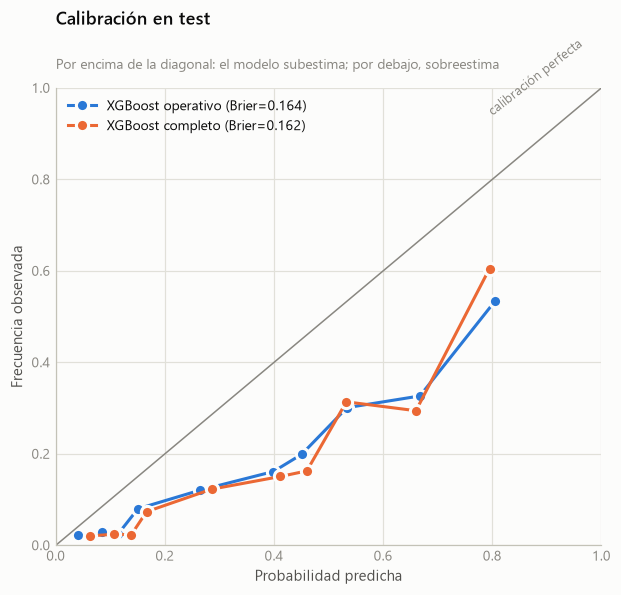

Con scale_pos_weight la probabilidad NO es una probabilidad de cumplimiento:
  media predicha por el modelo operativo : 0.345
  tasa real observada en test            : 0.172

Para reportar probabilidades interpretables hay que recalibrar (isotonica o Platt)
sobre un conjunto aparte. Para RANKEAR y priorizar gestion, la descalibracion no
afecta: el orden de los clientes es el mismo.


In [17]:
fig, ax = plt.subplots(figsize=(6.4, 5.4))
for p, color, nombre in [(p_op, AZUL, "XGBoost operativo"),
                         (p_full, NARANJA, "XGBoost completo")]:
    frac_pos, media_pred = calibration_curve(y_te, p, n_bins=10, strategy="quantile")
    ax.plot(media_pred, frac_pos, color=color, linewidth=2, marker="o", markersize=8,
            markerfacecolor=color, markeredgecolor=SUPERFICIE, markeredgewidth=2,
            label=f"{nombre} (Brier={brier_score_loss(y_te, p):.3f})")
ax.plot([0, 1], [0, 1], color=MUTED, linewidth=1)
ax.text(0.97, 0.94, "calibración perfecta", ha="right", fontsize=8.5, color=MUTED, rotation=38)
limpiar(ax)
ax.set_xlabel("Probabilidad predicha"); ax.set_ylabel("Frecuencia observada")
ax.set_xlim(0, 1); ax.set_ylim(0, 1)
ax.legend(loc="upper left")
titulos(ax, "Calibración en test",
        "Por encima de la diagonal: el modelo subestima; por debajo, sobreestima")
guardar(fig, "20_calibracion")
plt.show()

print("Con scale_pos_weight la probabilidad NO es una probabilidad de cumplimiento:")
print(f"  media predicha por el modelo operativo : {p_op.mean():.3f}")
print(f"  tasa real observada en test            : {y_te.mean():.3f}")
print("\nPara reportar probabilidades interpretables hay que recalibrar (isotonica o Platt)")
print("sobre un conjunto aparte. Para RANKEAR y priorizar gestion, la descalibracion no")
print("afecta: el orden de los clientes es el mismo.")

---
## 5 · Importancia de variables

Variables que el modelo nunca usa en un corte: ['tiene_conversacion']


figura -> outputs\figuras\21_importancia_ganancia.png


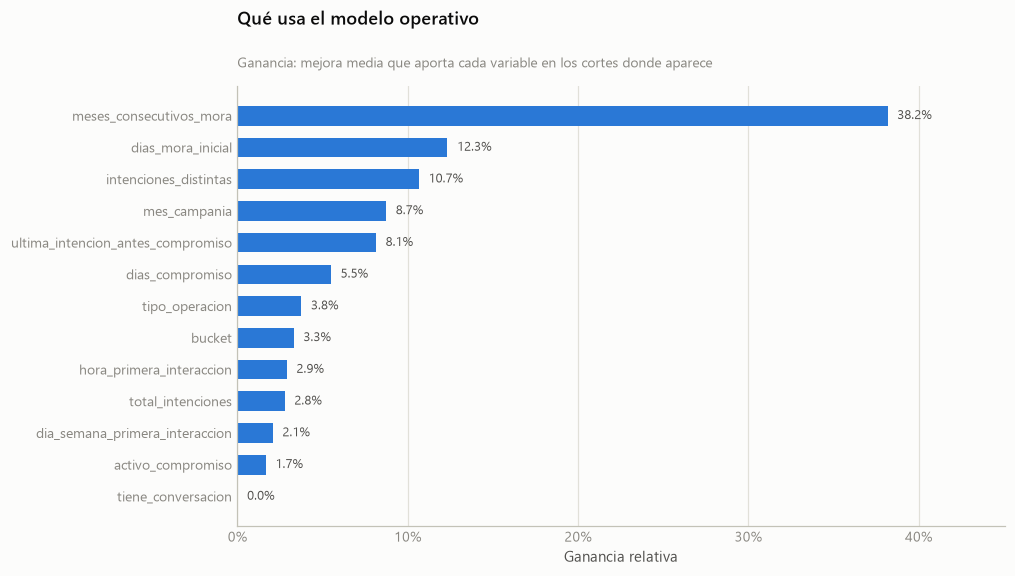

,variable,ganancia,peso_rel
7,meses_consecutivos_mora,126.4222,0.3818
6,dias_mora_inicial,40.8333,0.1233
1,intenciones_distintas,35.2880,0.1066
8,mes_campania,28.9025,0.0873
10,ultima_intencion_antes_compromiso,26.9266,0.0813
3,dias_compromiso,18.1818,0.0549
11,tipo_operacion,12.4205,0.0375
12,bucket,10.9561,0.0331
4,hora_primera_interaccion,9.5989,0.0290
0,total_intenciones,9.1928,0.0278


La ganancia mide uso interno, no efecto causal ni direccion. La interpretacion
con SHAP (valores con signo, por observacion) va en 04_interpretabilidad.ipynb.


In [18]:
# get_score solo devuelve las variables que aparecen en algun corte: se mapea por nombre
# para que las no usadas aparezcan con ganancia 0 en lugar de desalinear la tabla.
ganancias = mod_op.get_booster().get_score(importance_type="gain")
imp = (pd.DataFrame({"variable": mod_op.get_booster().feature_names})
       .assign(ganancia=lambda d: d["variable"].map(ganancias).fillna(0.0))
       .sort_values("ganancia", ascending=True))
imp["peso_rel"] = imp["ganancia"] / imp["ganancia"].sum()
sin_uso = imp.loc[imp["ganancia"] == 0, "variable"].tolist()
if sin_uso:
    print("Variables que el modelo nunca usa en un corte:", sin_uso)

fig, ax = plt.subplots(figsize=(9, 5.2))
ax.barh(imp["variable"], imp["peso_rel"], height=0.62, color=AZUL)
limpiar(ax)
ax.grid(axis="y", visible=False)
ax.xaxis.set_major_formatter(mpl.ticker.PercentFormatter(1.0, decimals=0))
ax.set_xlabel("Ganancia relativa")
for y, v in enumerate(imp["peso_rel"]):
    ax.text(v + imp["peso_rel"].max() * 0.015, y, f"{v:.1%}", va="center",
            fontsize=8.5, color=TINTA_2)
ax.set_xlim(0, imp["peso_rel"].max() * 1.18)
titulos(ax, "Qué usa el modelo operativo",
        "Ganancia: mejora media que aporta cada variable en los cortes donde aparece")
guardar(fig, "21_importancia_ganancia")
plt.show()

display(imp.sort_values("ganancia", ascending=False).round(4))
print("La ganancia mide uso interno, no efecto causal ni direccion. La interpretacion")
print("con SHAP (valores con signo, por observacion) va en 04_interpretabilidad.ipynb.")

---
## 6 · Comparación contra el proxy `cumplimiento_ceroteo`

El proxy interno tiene kappa 0,571 con el target real. Entrenar contra él responde a una pregunta
concreta de la memoria: **¿cuánto cambia el modelo si se usa el atajo?**

In [19]:
y_tr_p, y_te_p = tr[PROXY].to_numpy(), te[PROXY].to_numpy()
spw_p = (y_tr_p == 0).sum() / (y_tr_p == 1).sum()

mod_proxy = xgb.XGBClassifier(
    objective="binary:logistic", eval_metric="aucpr", tree_method="hist",
    enable_categorical=True, scale_pos_weight=spw_p, random_state=SEMILLA, n_jobs=N_JOBS_MODELO,
    **{k: v for k, v in busq_op.best_params_.items()},
).fit(preparar(tr, FEATURES_OPERATIVO), y_tr_p)

p_proxy = mod_proxy.predict_proba(preparar(te, FEATURES_OPERATIVO))[:, 1]

print("Modelo entrenado contra el PROXY, evaluado contra el PROXY:")
print(f"   PR-AUC {average_precision_score(y_te_p, p_proxy):.4f} "
      f"(tasa base {y_te_p.mean():.4f}, lift {average_precision_score(y_te_p, p_proxy)/y_te_p.mean():.2f})")
print("\nEl mismo modelo, evaluado contra el TARGET REAL:")
print(f"   PR-AUC {average_precision_score(y_te, p_proxy):.4f} "
      f"(lift {average_precision_score(y_te, p_proxy)/y_te.mean():.2f})")
print("\nModelo entrenado contra el TARGET REAL, evaluado contra el TARGET REAL:")
print(f"   PR-AUC {average_precision_score(y_te, p_op):.4f} "
      f"(lift {average_precision_score(y_te, p_op)/y_te.mean():.2f})")

print("\nCorrelacion de Spearman entre los dos rankings:",
      round(pd.Series(p_op).corr(pd.Series(p_proxy), method="spearman"), 4))
print("\nSi el ranking del proxy fuera equivalente, entrenar con el atajo daria igual.")
print("La diferencia de PR-AUC contra el target real cuantifica el costo de usarlo.")

Modelo entrenado contra el PROXY, evaluado contra el PROXY:
   PR-AUC 0.4478 (tasa base 0.1941, lift 2.31)

El mismo modelo, evaluado contra el TARGET REAL:
   PR-AUC 0.4141 (lift 2.40)

Modelo entrenado contra el TARGET REAL, evaluado contra el TARGET REAL:
   PR-AUC 0.3923 (lift 2.27)

Correlacion de Spearman entre los dos rankings: 0.9604

Si el ranking del proxy fuera equivalente, entrenar con el atajo daria igual.
La diferencia de PR-AUC contra el target real cuantifica el costo de usarlo.


---
## 7 · Guardado y resumen

In [20]:
modelo_final = {
    "modelo": mod_op,
    "features": FEATURES_OPERATIVO,
    "categoricas": CATEGORICAS,
    "target": TARGET,
    "scale_pos_weight": float(spw),
    "mes_corte": MES_CORTE,
    "hiperparametros": busq_op.best_params_,
    "nota": ("Modelo operativo: excluye activo_ya_pague por fuga temporal "
             "(mediana 0 dias respecto de fecha_pago)."),
}
ruta_modelo = DIR_MODELOS / "xgboost_cumplimiento_v1.pkl"
joblib.dump(modelo_final, ruta_modelo)
print("Modelo guardado:", ruta_modelo.relative_to(RAIZ))

metricas = {
    "dataset": {"filas": len(df), "clientes": int(df[GRUPO].nunique()),
                "positivos": float(df[TARGET].mean())},
    "split": {"corte": MES_CORTE, "train": len(tr), "test": len(te),
              "positivos_train": float(y_tr.mean()), "positivos_test": float(y_te.mean())},
    "cv_pr_auc": {"operativo_temporal": float(busq_op.best_score_),
                  "operativo_grupos": float(busq_grupo.best_score_),
                  "completo_temporal": float(busq_full.best_score_)},
    "test": pd.DataFrame(resultados).set_index("modelo").to_dict("index"),
    "capacidad_20pct_operativo": curva_capacidad(y_te, p_op).query("capacidad == '20%'").to_dict("records")[0],
    "significancia": comparaciones,
    "estabilidad_mensual": estabilidad.to_dict("records"),
    # los guarda este notebook porque el 06 los necesita para reconstruir cada
    # modelo con SUS hiperparametros y no con los del operativo
    "hiperparametros": {
        "operativo · CV temporal": busq_op.best_params_,
        "operativo · CV aleatoria por grupos": busq_grupo.best_params_,
        "completo · CV temporal": busq_full.best_params_,
        "operativo monotono": busq_mono.best_params_,
        "completo monotono": busq_mono_full.best_params_,
    },
}
ruta_metricas = DIR_OUTPUTS / "metricas_modelo_v1.json"
ruta_metricas.write_text(json.dumps(metricas, indent=2, ensure_ascii=False), encoding="utf-8")
print("Metricas guardadas:", ruta_metricas.relative_to(RAIZ))
display(pd.DataFrame(resultados).set_index("modelo").round(4))

Modelo guardado: modelos\xgboost_cumplimiento_v1.pkl
Metricas guardadas: outputs\metricas_modelo_v1.json


,PR_AUC,ROC_AUC,Brier
modelo,,,
Tasa base (dummy),0.1725,0.5000,0.1457
Logistica operativa,0.4209,0.7644,0.1421
Logistica completa,0.4543,0.7724,0.1377
XGBoost operativo · CV aleatoria,0.3782,0.7648,0.1601
XGBoost operativo · CV temporal,0.3923,0.7751,0.1635
XGBoost operativo · monotono,0.3895,0.7737,0.1665
XGBoost completo · CV temporal,0.4458,0.7912,0.1616
XGBoost completo · monotono,0.4067,0.7816,0.1623


In [21]:
brecha = average_precision_score(y_te, p_full) - average_precision_score(y_te, p_op)
fila20 = curva_capacidad(y_te, p_op).query("capacidad == '20%'").iloc[0]

print("=" * 74)
print("RESUMEN")
print("=" * 74)
print(f"""
Todos los modelos superan claramente al azar (tasa base {y_te.mean():.4f}), pero el
orden no es el esperado:

   Logistica completa               PR-AUC {average_precision_score(y_te, p_logit_full):.4f}   <- mejor
   XGBoost completo                 PR-AUC {average_precision_score(y_te, p_full):.4f}
   Logistica operativa              PR-AUC {average_precision_score(y_te, p_logit):.4f}
   XGBoost operativo                PR-AUC {average_precision_score(y_te, p_op):.4f}

1) La linea base lineal le gana a XGBoost con los dos conjuntos de variables.
   Se probo cerrar la brecha con restricciones de monotonia y NO funciono
   ({average_precision_score(y_te, p_mono) - average_precision_score(y_te, p_op):+.4f} en el operativo,
   {average_precision_score(y_te, p_mono_full) - average_precision_score(y_te, p_full):+.4f} en el completo): la forma de las relaciones no
   es el problema. Queda en pie la explicacion de volumen: 11.078 filas y 13
   variables no alcanzan para que el boosting estime interacciones estables,
   con una tasa base que ademas cae de 22.7% en train a 17.3% en test.

2) La brecha entre completo y operativo ({brecha:+.4f} en XGBoost) es el desempeno
   que NO se puede reproducir en produccion: activo_ya_pague se activa cuando el
   pago ya ocurrio (mediana 0 dias respecto de fecha_pago).

3) La CV aleatoria por grupos exageraba: prometia {busq_grupo.best_score_:.4f} y entrego
   {average_precision_score(y_te, p_grupo):.4f}. La CV temporal prometia {busq_op.best_score_:.4f} y entrego
   {average_precision_score(y_te, p_op):.4f}. Mismo desempeno final, la mitad de optimismo.

Uso operativo (XGBoost operativo, top 20% de la cartera):
   captura {int(fila20['cumplidores_capturados'])} de los {int(y_te.sum())} cumplidores ({fila20['recall']:.1%} de recall)
   con {fila20['precision']:.1%} de precision, {fila20['lift']:.2f} veces la tasa base.

Para la memoria: reportar la tabla completa con la linea base al lado. Que un
modelo lineal aproveche mejor estas variables es informacion sobre el problema,
no un fracaso del trabajo: la contribucion son las variables conversacionales y
el pipeline que las construye.
""")

RESUMEN

Todos los modelos superan claramente al azar (tasa base 0.1725), pero el
orden no es el esperado:

   Logistica completa               PR-AUC 0.4543   <- mejor
   XGBoost completo                 PR-AUC 0.4458
   Logistica operativa              PR-AUC 0.4209
   XGBoost operativo                PR-AUC 0.3923

1) La linea base lineal le gana a XGBoost con los dos conjuntos de variables.
   Se probo cerrar la brecha con restricciones de monotonia y NO funciono
   (-0.0028 en el operativo,
   -0.0391 en el completo): la forma de las relaciones no
   es el problema. Queda en pie la explicacion de volumen: 11.078 filas y 13
   variables no alcanzan para que el boosting estime interacciones estables,
   con una tasa base que ademas cae de 22.7% en train a 17.3% en test.

2) La brecha entre completo y operativo (+0.0535 en XGBoost) es el desempeno
   que NO se puede reproducir en produccion: activo_ya_pague se activa cuando el
   pago ya ocurrio (mediana 0 dias respecto de fecha_pago

---
### Siguiente fase

`04_interpretabilidad.ipynb`, con valores SHAP sobre el modelo operativo, dependencia parcial de las
variables conversacionales y conclusiones para la memoria.